# Assignment Lab 4
## Data Quality Assessment and Preprocessing using Ames Housing Dataset

# Load the Dataset

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AmesHousing.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Task 1
Identify Data Quality Issues

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [52]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [53]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [54]:
df.duplicated().sum()

np.int64(0)

The Ames Housing dataset contains information about residential properties including house size, number of rooms, lot area, and sale price. The target variable is SalePrice, which represents the selling price of the house. Data quality issues may include missing values in several columns, duplicated rows, and potential outliers in numerical features such as sale price and living area.

# Task 2
Handle Missing Values

In [57]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].mean())
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(df['Garage Yr Blt'].mean())
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(df['Mas Vnr Area'].mean())

In [58]:
df['Alley'] = df['Alley'].fillna(df['Alley'].mode()[0])
df['Bsmt Qual'] = df['Bsmt Qual'].fillna(df['Bsmt Qual'].mode()[0])
df['Bsmt Cond'] = df['Bsmt Cond'].fillna(df['Bsmt Cond'].mode()[0])
df['Bsmt Exposure'] = df['Bsmt Exposure'].fillna(df['Bsmt Exposure'].mode()[0])
df['Garage Type'] = df['Garage Type'].fillna(df['Garage Type'].mode()[0])
df['Garage Finish'] = df['Garage Finish'].fillna(df['Garage Finish'].mode()[0])
df['Garage Qual'] = df['Garage Qual'].fillna(df['Garage Qual'].mode()[0])
df['Garage Cond'] = df['Garage Cond'].fillna(df['Garage Cond'].mode()[0])
df['Fireplace Qu'] = df['Fireplace Qu'].fillna(df['Fireplace Qu'].mode()[0])
df['Pool QC'] = df['Pool QC'].fillna(df['Pool QC'].mode()[0])
df['Fence'] = df['Fence'].fillna(df['Fence'].mode()[0])
df['Misc Feature'] = df['Misc Feature'].fillna(df['Misc Feature'].mode()[0])

In [59]:
df.isnull().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64

Missing values were handled based on the data type of each feature. Numerical columns such as Lot Frontage, Garage Yr Blt, and Mas Vnr Area were filled using the mean value. Categorical columns such as Alley, Bsmt Qual, and Garage Type were filled using the mode. This approach helps preserve the overall structure of the dataset and ensures that no missing values remain before further preprocessing.

# Task 3
Detect and Handle Outliers using IQR

In [60]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 129500.0
Q3: 213500.0
IQR: 84000.0
Lower Bound: 3500.0
Upper Bound: 339500.0


In [61]:
outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]
print("Number of outliers:", outliers.shape[0])

Number of outliers: 137


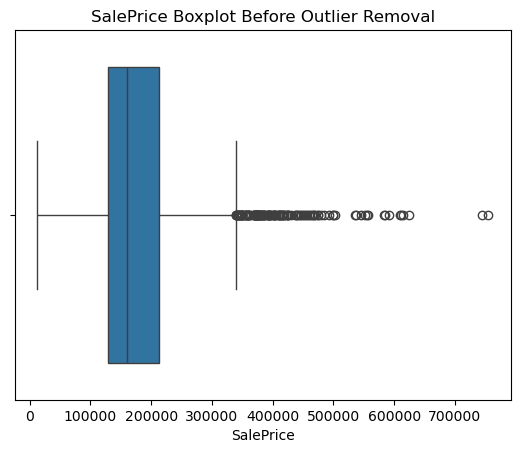

In [62]:
sns.boxplot(x=df['SalePrice'])
plt.title("SalePrice Boxplot Before Outlier Removal")
plt.show()

In [63]:
df = df[(df['SalePrice'] >= lower_bound) & (df['SalePrice'] <= upper_bound)]

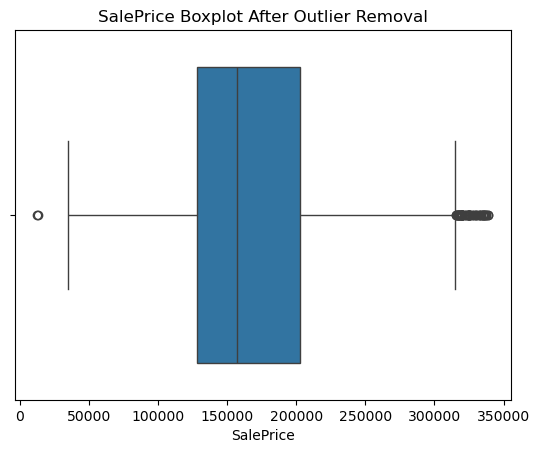

In [64]:
sns.boxplot(x=df['SalePrice'])
plt.title("SalePrice Boxplot After Outlier Removal")
plt.show()

Outliers were detected in the SalePrice feature using the Interquartile Range (IQR) method. Values below the lower bound or above the upper bound were considered outliers. These values were removed to improve the quality of the dataset and reduce the effect of extreme values on the analysis.

# Task 4
Normalize Numerical Features using Min-Max and Z-score

Select numerical features

In [82]:
numerical_features = ['SalePrice', 'Gr Liv Area', 'Lot Area', 'Garage Area', 'Total Bsmt SF']

1. Min-Max Normalization

In [83]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numerical_features] = minmax_scaler.fit_transform(df[numerical_features])

df_minmax[numerical_features].head()

,SalePrice,Gr Liv Area,Lot Area,Garage Area,Total Bsmt SF
0,0.620009,0.249058,0.186521,0.354839,0.176759
1,0.282733,0.105878,0.063186,0.490591,0.144354
2,0.488165,0.187453,0.079377,0.209677,0.217512
3,0.708927,0.334589,0.060357,0.350806,0.345336
4,0.543049,0.243971,0.076702,0.323925,0.151882


2. Z-score Standardization

In [84]:
df_pca_input = df_zscore[numerical_features].dropna()

In [85]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[numerical_features] = zscore_scaler.fit_transform(df[numerical_features])

df_zscore[numerical_features].head()

,SalePrice,Gr Liv Area,Lot Area,Garage Area,Total Bsmt SF
0,0.777987,0.436866,3.215348,0.353705,0.163147
1,-1.087100,-1.214510,0.259011,1.347864,-0.325560
2,0.048908,-0.273660,0.647114,-0.709356,0.777735
3,1.269692,1.423347,0.191221,0.324176,2.705416
4,0.352408,0.378199,0.582993,0.127312,-0.212022


Two normalization techniques were applied to the numerical features. Min-Max scaling was used to transform the values into a range between 0 and 1. Z-score standardization was also applied to transform the data so that it has a mean of 0 and a standard deviation of 1. These methods help prepare the data for machine learning algorithms.

# Task 5
Apply PCA only if the numerical features show correlation

In [86]:
corr_matrix = df[numerical_features].corr()
corr_matrix

,SalePrice,Gr Liv Area,Lot Area,Garage Area,Total Bsmt SF
SalePrice,1.000000,0.652255,0.241337,0.605603,0.549858
Gr Liv Area,0.652255,1.000000,0.285918,0.420891,0.365498
Lot Area,0.241337,0.285918,1.000000,0.207522,0.234384
Garage Area,0.605603,0.420891,0.207522,1.000000,0.417442
Total Bsmt SF,0.549858,0.365498,0.234384,0.417442,1.000000


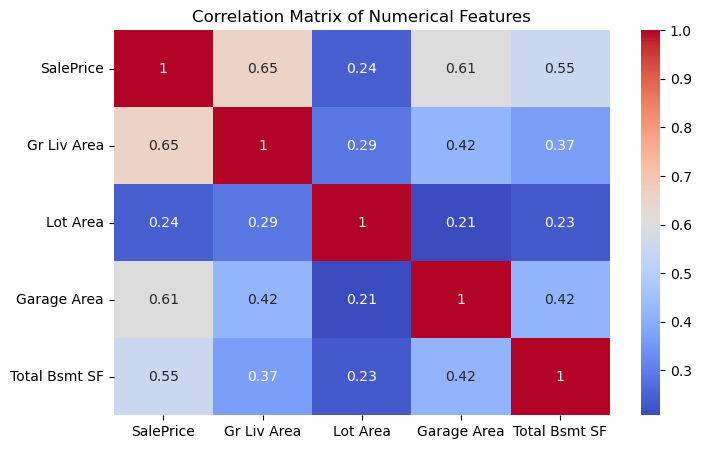

In [87]:
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()

The correlation matrix was used to examine the relationships between numerical features. Since some of the selected features show correlation, PCA can be applied to reduce dimensionality and remove redundancy while preserving the most important information.

# Apply PCA

In [88]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_pca_input)

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,1.760403,2.780790
1,-0.610768,0.172148
2,0.090522,0.681674
3,2.749156,-0.444669
4,0.497572,0.475356


In [89]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.53217138 0.17421675]


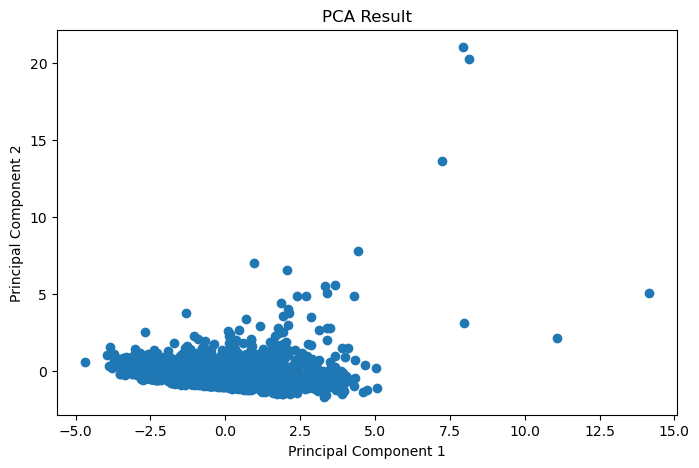

In [90]:
plt.figure(figsize=(8,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title("PCA Result")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

PCA was applied because the selected numerical features showed correlation. The original numerical features were transformed into two principal components. This helps reduce dimensionality while preserving most of the variance in the data.